# Chirundu Town Council CDF Community Projects - 2022

## Purpose

This notebook extracts, cleans, validates and exports approved
CDF community project information published by Chirundu Town Council.

The source PDF is scanned, therefore OCR is used to extract the text
before the records are cleaned and structured.

## Final Dataset Fields

- project_name
- ward
- year
- approval_status
- project_type

In [1]:
import os
import pymupdf
import pytesseract
import pandas as pd
import cv2
import numpy as np

from PIL import Image
from IPython.display import display

pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Program Files\Tesseract-OCR\tesseract.exe"
)

print("Libraries loaded successfully.")
print("Tesseract version:", pytesseract.get_tesseract_version())

Libraries loaded successfully.
Tesseract version: 5.4.0.20240606


## Source Document

The source document is the 2022 Chirundu Town Council approved CDF
community projects PDF.

The document is scanned, so direct text extraction may return little
or no useful text. OCR is therefore used.

In [2]:
pdf_path = "raw/2022-CDF-approved-projects.pdf"

print("File exists:", os.path.exists(pdf_path))

File exists: True


In [3]:
doc = pymupdf.open(pdf_path)

print("PDF opened successfully.")
print("Number of pages:", len(doc))

PDF opened successfully.
Number of pages: 1


## Direct Text Extraction Test

Before OCR is applied, the notebook checks whether useful
machine-readable text can be extracted directly from the PDF.

Because the source is scanned, little or no useful text is expected.

In [4]:
for page_number, page in enumerate(doc):
    text = page.get_text().strip()

    print(
        f"Page {page_number + 1}:",
        len(text),
        "characters detected"
    )

Page 1: 0 characters detected


## OCR Extraction

The scanned PDF page is converted to a high-resolution image and
processed using Tesseract OCR.

The OCR output is reviewed against the original PDF because OCR may
misread characters, merge text or omit some information.

In [5]:
os.makedirs("notebooks/2022_ocr", exist_ok=True)

page = doc[0]

matrix = pymupdf.Matrix(3, 3)

pix = page.get_pixmap(
    matrix=matrix,
    alpha=False
)

image_path = "notebooks/2022_ocr/2022_cdf_page1.png"

pix.save(image_path)

print("Page image saved successfully:")
print(image_path)

Page image saved successfully:
notebooks/2022_ocr/2022_cdf_page1.png


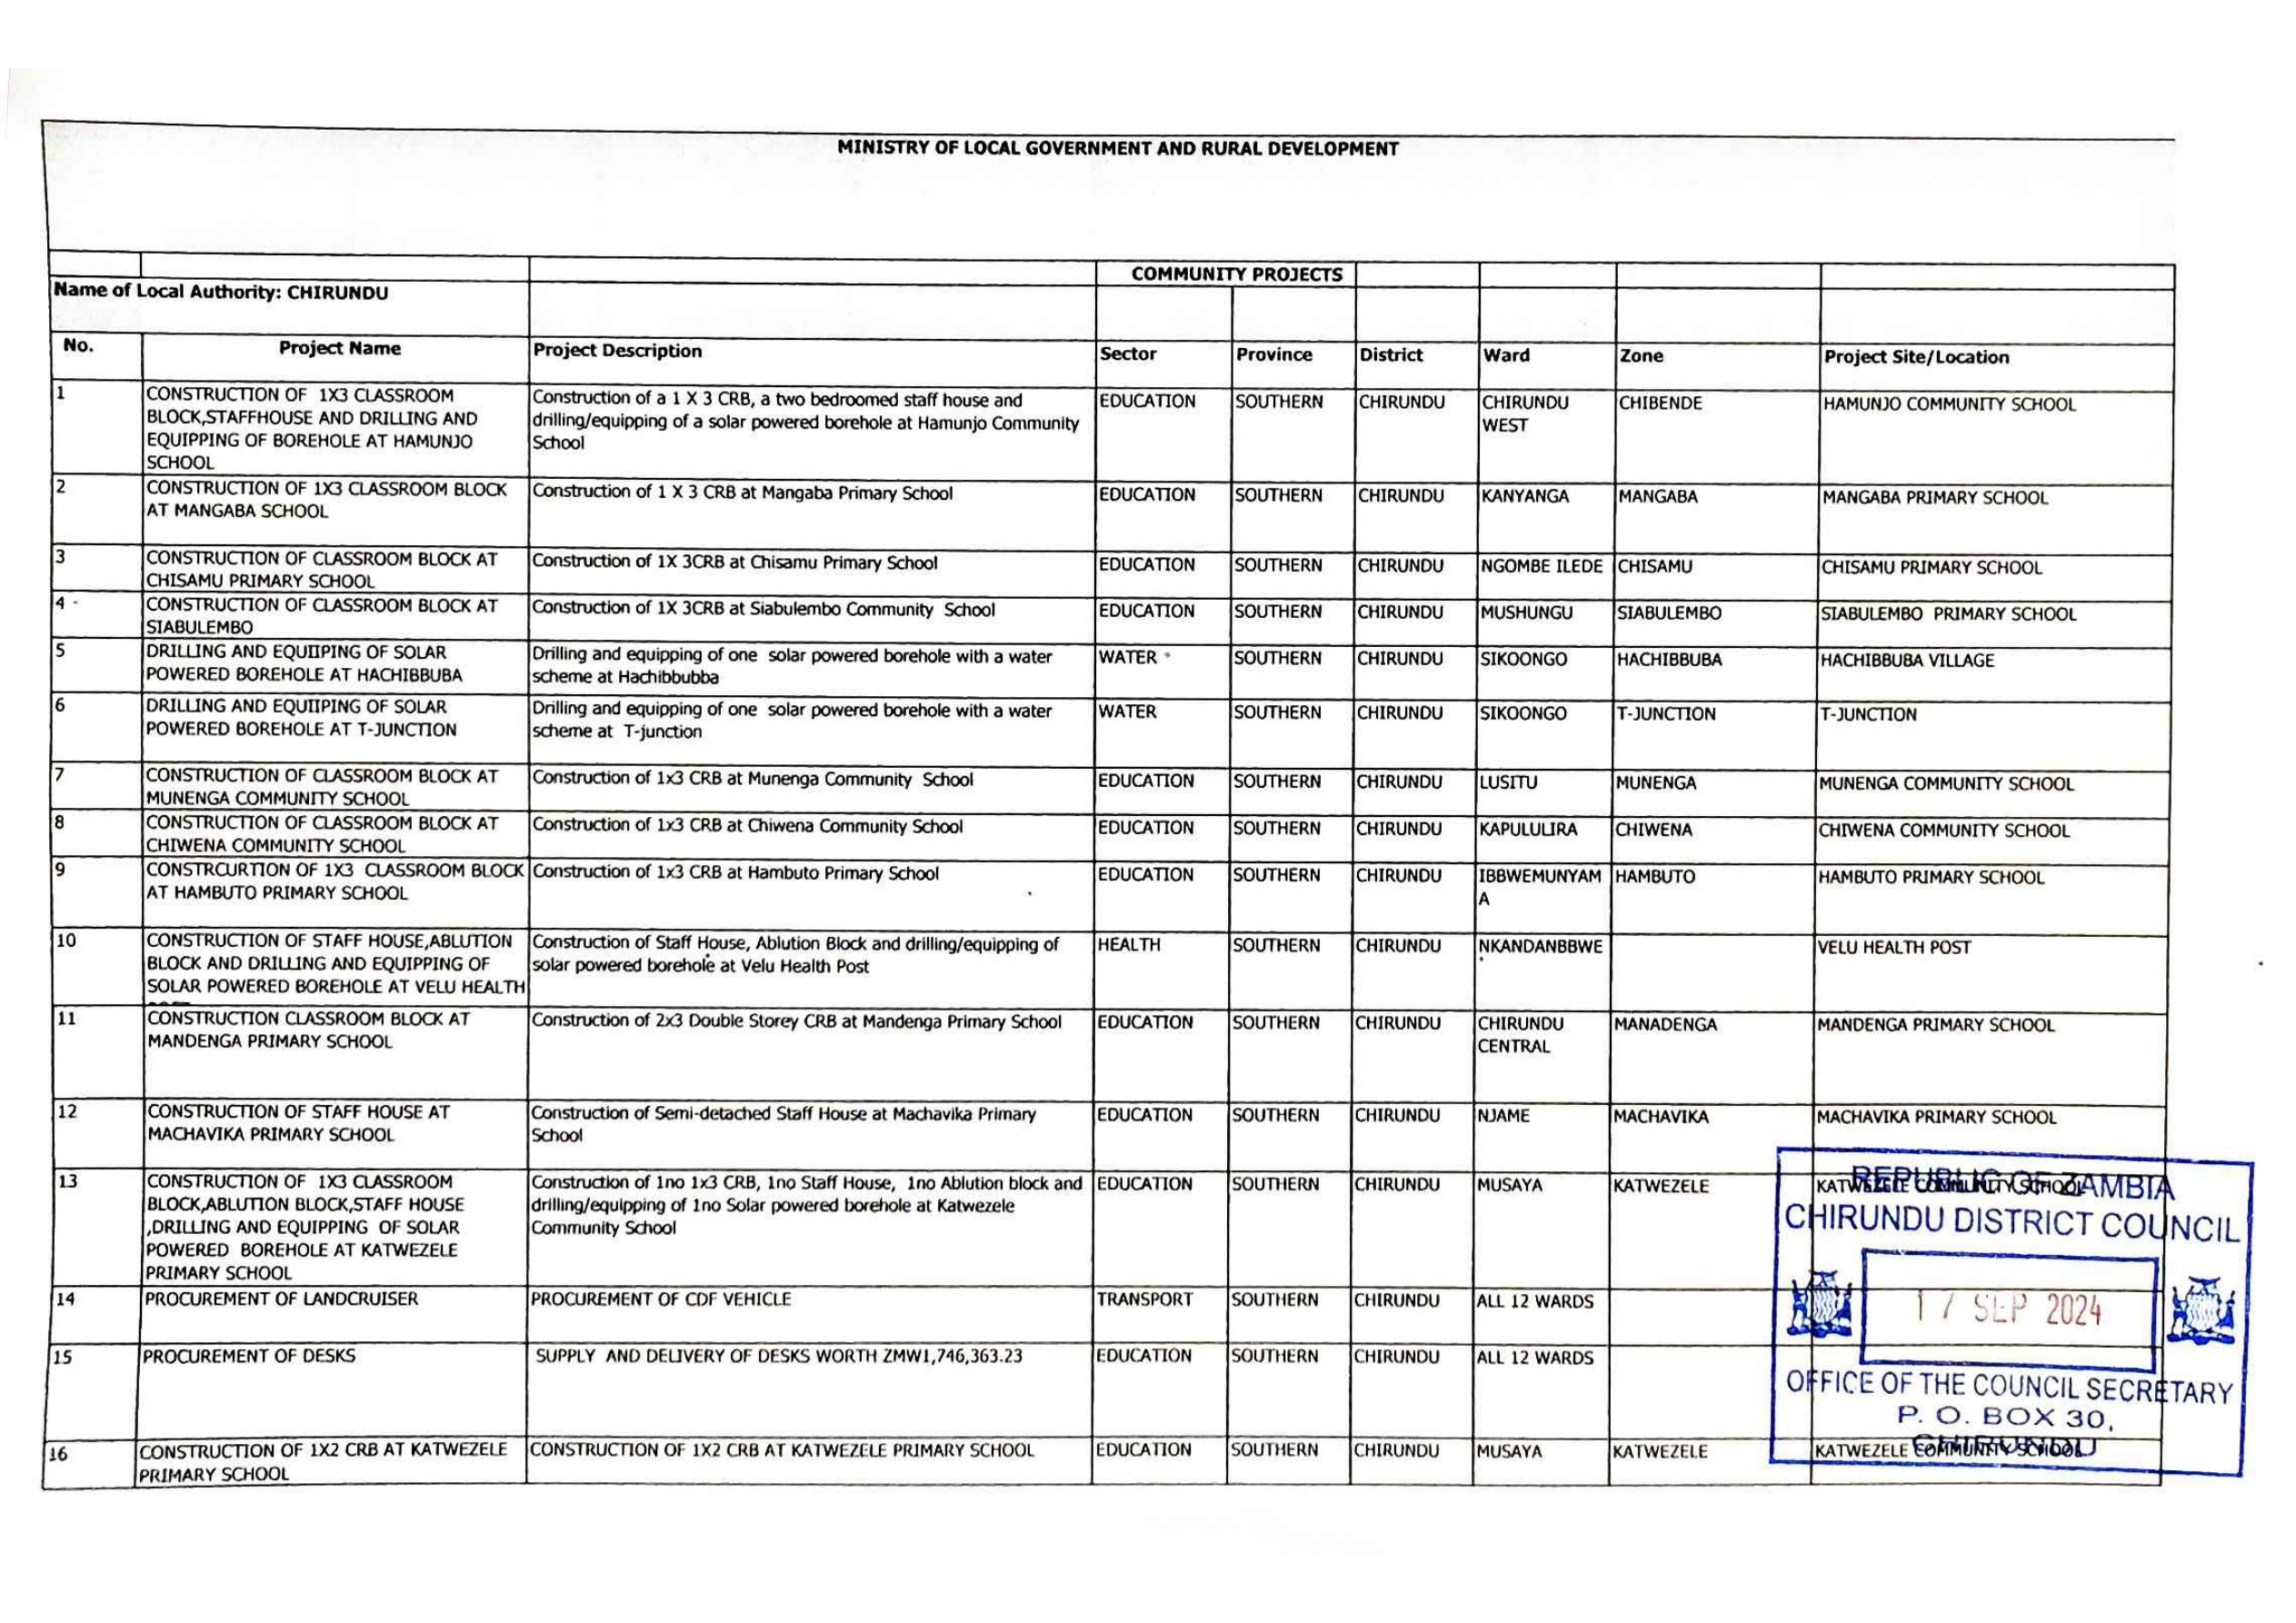

In [6]:
page_image = Image.open(image_path)

display(page_image)

In [7]:
image = cv2.imread(image_path)

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

ocr_text_2022 = pytesseract.image_to_string(
    gray,
    lang="eng",
    config="--psm 6"
)

print(ocr_text_2022)

MINISTRY OF LOCAL GOVERNMENT AND RURAL DEVELOPMENT
Peony Proaicrs eneeed lei (ee) |
CONSTRUCTION OF 1X3 CLASSROOM Construction of a 1 X 3 CRB, a two bedroomed staff house and IEOUCATION = [SOUTHERN = [CHIRUNDU —[CHIRUNDU CHIBENDE HAMUNJO COMMUNITY SCHOOL
BLOCK,STAFFHOUSE AND DRILLING AND drilling/equipping of a solar powered borehole at Hamunjo Community WEST
EQUIPPING OF BOREHOLE AT HAMUNJO School
SCHOOL
2 CONSTRUCTION OF 1X3 CLASSROOM BLOCK Construction of 1 X 3 CRB at Mangaba Primary School EDUCATION [SOUTHERN |CHIRUNDU  |KANYANGA MANGABA MANGABA PRIMARY SCHOOL
AT MANGABA SCHOOL
CONSTRUCTION OF CLASSROOM BLOCK AT — [Construction of 1X 3CRB at Chisamu Primary School EDUCATION SOUTHERN [CHIRUNDU  [NGOMBE ILEDE |CHISAMU CHISAMU PRIMARY SCHOOL
ICHISAMU PRIMARY SCHOOL
f | CONSTRUCTION OF CLASSROOM BLOCK AT —_ Construction of 1X 3CRB at Siabulembo Community School EDUCATION [SOUTHERN |CHIRUNDU |MUSHUNGU — [SIABULEMBO SIABULEMBO PRIMARY SCHOOL
ISIABULEMBO.
DRILLING AND EQUIIPING OF SOLAR D

In [8]:
ocr_output_path = (
    "notebooks/2022_ocr/"
    "2022_ocr_page1.txt"
)

with open(
    ocr_output_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(ocr_text_2022)

print("Raw OCR text saved successfully:")
print(ocr_output_path)

Raw OCR text saved successfully:
notebooks/2022_ocr/2022_ocr_page1.txt


## Data Cleaning and Curation

The OCR output was compared with the original 2022 PDF table.

OCR errors, incorrect characters and unclear text were corrected using
the source document.

The following fields were used:

- `project_name`: extracted from the project name field.
- `ward`: extracted from the ward field.
- `year`: assigned as 2022 from the source document year.
- `approval_status`: assigned as `Approved` because the source contains
  approved CDF projects.
- `project_type`: mapped from the Sector field in the source document.

In [9]:
projects_2022 = [
    {
        "project_name": "Construction of 1x3 Classroom Block, Staff House and Drilling and Equipping of Borehole at Hamunjo School",
        "ward": "Chirundu West",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of 1x3 Classroom Block at Mangaba School",
        "ward": "Kanyanga",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of Classroom Block at Chisamu Primary School",
        "ward": "Ngombe Ilede",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of Classroom Block at Siabulembo Primary School",
        "ward": "Mushungu",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Drilling and Equipping of Solar Powered Borehole at Hachibbuba",
        "ward": "Sikoongo",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Water"
    },
    {
        "project_name": "Drilling and Equipping of Solar Powered Borehole at T-Junction",
        "ward": "Sikoongo",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Water"
    },
    {
        "project_name": "Construction of Classroom Block at Munenga Community School",
        "ward": "Lusitu",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of Classroom Block at Chiwena Community School",
        "ward": "Kapululira",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of 1x3 Classroom Block at Hambuto Primary School",
        "ward": "Ibwemunyama",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of Staff House, Ablution Block and Drilling and Equipping of Solar Powered Borehole at Velu Health Post",
        "ward": "Nkandanbbwe",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Health"
    },
    {
        "project_name": "Construction Classroom Block at Mandenga Primary School",
        "ward": "Chirundu Central",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of Staff House at Machavika Primary School",
        "ward": "Njame",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of 1x3 Classroom Block, Ablution Block, Staff House, Drilling and Equipping of Solar Powered Borehole at Katwezele Primary School",
        "ward": "Musaya",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Procurement of Landcruiser",
        "ward": "All 12 Wards",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Transport"
    },
    {
        "project_name": "Procurement of Desks",
        "ward": "All 12 Wards",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Education"
    },
    {
        "project_name": "Construction of 1x2 CRB at Katwezele Primary School",
        "ward": "Musaya",
        "year": 2022,
        "approval_status": "Approved",
        "project_type": "Education"
    }
]

df_2022 = pd.DataFrame(projects_2022)

display(df_2022)

,project_name,ward,year,approval_status,project_type
0,"Construction of 1x3 Classroom Block, Staff Hou...",Chirundu West,2022,Approved,Education
1,Construction of 1x3 Classroom Block at Mangaba...,Kanyanga,2022,Approved,Education
2,Construction of Classroom Block at Chisamu Pri...,Ngombe Ilede,2022,Approved,Education
3,Construction of Classroom Block at Siabulembo ...,Mushungu,2022,Approved,Education
4,Drilling and Equipping of Solar Powered Boreho...,Sikoongo,2022,Approved,Water
5,Drilling and Equipping of Solar Powered Boreho...,Sikoongo,2022,Approved,Water
6,Construction of Classroom Block at Munenga Com...,Lusitu,2022,Approved,Education
7,Construction of Classroom Block at Chiwena Com...,Kapululira,2022,Approved,Education
8,Construction of 1x3 Classroom Block at Hambuto...,Ibwemunyama,2022,Approved,Education
9,"Construction of Staff House, Ablution Block an...",Nkandanbbwe,2022,Approved,Health


## Data Validation

The cleaned dataset is checked for:

- expected number of project records
- correct column structure
- missing values
- duplicate records
- year consistency
- approval status consistency
- project type values
- ward values

In [10]:
print("Dataset shape:", df_2022.shape)

print("\nColumns:")
print(df_2022.columns.tolist())

print("\nMissing values:")
print(df_2022.isnull().sum())

print("\nDuplicate rows:")
print(df_2022.duplicated().sum())

print("\nYear values:")
print(df_2022["year"].value_counts())

print("\nApproval status:")
print(df_2022["approval_status"].value_counts())

print("\nProject types:")
print(df_2022["project_type"].value_counts())

print("\nWards:")
print(df_2022["ward"].value_counts())

Dataset shape: (16, 5)

Columns:
['project_name', 'ward', 'year', 'approval_status', 'project_type']

Missing values:
project_name       0
ward               0
year               0
approval_status    0
project_type       0
dtype: int64

Duplicate rows:
0

Year values:
year
2022    16
Name: count, dtype: int64

Approval status:
approval_status
Approved    16
Name: count, dtype: int64

Project types:
project_type
Education    12
Water         2
Health        1
Transport     1
Name: count, dtype: int64

Wards:
ward
Sikoongo            2
Musaya              2
All 12 Wards        2
Chirundu West       1
Kanyanga            1
Ngombe Ilede        1
Mushungu            1
Lusitu              1
Kapululira          1
Ibwemunyama         1
Nkandanbbwe         1
Chirundu Central    1
Njame               1
Name: count, dtype: int64


In [11]:
expected_columns = [
    "project_name",
    "ward",
    "year",
    "approval_status",
    "project_type"
]

if list(df_2022.columns) == expected_columns:
    print("Column structure is correct.")
else:
    print("Column structure needs correction.")

Column structure is correct.


## Export Final Dataset

The cleaned dataset is exported in CSV format using the pipe character
`|` as the column separator.

The filename follows the naming convention required by the assignment.

In [12]:
os.makedirs("processed", exist_ok=True)

output_path = (
    "processed/"
    "db-unza26-csc4792-chirundu_cdf_projects_2022.csv"
)

df_2022.to_csv(
    output_path,
    sep="|",
    index=False,
    encoding="utf-8"
)

print("Dataset exported successfully:")
print(output_path)

Dataset exported successfully:
processed/db-unza26-csc4792-chirundu_cdf_projects_2022.csv


In [13]:
final_check = pd.read_csv(
    output_path,
    sep="|"
)

print("Rows:", len(final_check))
print("Columns:", len(final_check.columns))

display(final_check)

Rows: 16
Columns: 5


,project_name,ward,year,approval_status,project_type
0,"Construction of 1x3 Classroom Block, Staff Hou...",Chirundu West,2022,Approved,Education
1,Construction of 1x3 Classroom Block at Mangaba...,Kanyanga,2022,Approved,Education
2,Construction of Classroom Block at Chisamu Pri...,Ngombe Ilede,2022,Approved,Education
3,Construction of Classroom Block at Siabulembo ...,Mushungu,2022,Approved,Education
4,Drilling and Equipping of Solar Powered Boreho...,Sikoongo,2022,Approved,Water
5,Drilling and Equipping of Solar Powered Boreho...,Sikoongo,2022,Approved,Water
6,Construction of Classroom Block at Munenga Com...,Lusitu,2022,Approved,Education
7,Construction of Classroom Block at Chiwena Com...,Kapululira,2022,Approved,Education
8,Construction of 1x3 Classroom Block at Hambuto...,Ibwemunyama,2022,Approved,Education
9,"Construction of Staff House, Ablution Block an...",Nkandanbbwe,2022,Approved,Health


In [14]:
print("Final verification")

print(
    "Same number of rows:",
    len(final_check) == len(df_2022)
)

print(
    "Same columns:",
    list(final_check.columns) == list(df_2022.columns)
)

print(
    "Missing values:",
    final_check.isnull().sum().sum()
)

print(
    "Duplicates:",
    final_check.duplicated().sum()
)

Final verification
Same number of rows: True
Same columns: True
Missing values: 0
Duplicates: 0


## Conclusion

The 2022 Chirundu Town Council approved CDF community projects were
successfully extracted, cleaned, structured and validated.

The final dataset contains 16 project records and 5 fields.

The `project_type` values were obtained from the Sector field in the
source document.

The final CSV was exported using the required pipe (`|`) separator and
read back into Pandas to verify the output.